# Comparative Analysis of Synthetic Data Trials
**Author:** Ayemhenre Isikhuemhen  
**Trials:** Trial 1 · Trial 2 · Trial 3 · Trial 4  
**Reference Dataset:** SFMTA Ridership by Route (Empirical)  
**Source:** Valmistada Synthetic Data Simulation — SD_Game Output  

**File Description:** This notebook performs a comprehensive comparative analysis of four synthetic simulation trials generated by the Valmistada transit simulation engine for the San Francisco MUNI network. Each trial is examined individually for its boarding distributions and route-level demand profiles, then evaluated collectively against the empirical SFMTA ridership dataset. The final section assesses fidelity across trials using rank charts, correlation matrices, error heatmaps, and a normalised performance radar.

---

## Setup
**Setup for the comparative analysis notebook: Import Libraries & File Paths**

In [1]:
# Library Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Plotting style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print("Libraries Imported")

Libraries Imported


In [2]:
# File Paths

# Update BASE_DIR and MODIFIER_DIR if running on a different machine.
BASE_DIR     = r"C:\Users\Owner\Documents\GitHub\Valmistada\SD_Game\output\trials"
MODIFIER_DIR = r"C:\Users\Owner\Documents\GitHub\Valmistada\Data Exploration\Modifier Data\San Francisco"

import os

TRIAL_DIRS = {
    "Trial 1": os.path.join(BASE_DIR, "trial_1"),
    "Trial 2": os.path.join(BASE_DIR, "trial_2"),
    "Trial 3": os.path.join(BASE_DIR, "trial_3"),
    "Trial 4": os.path.join(BASE_DIR, "trial_4"),
}

RIDERSHIP_PATH = os.path.join(MODIFIER_DIR, "RidershipbyRouteTableDownload.csv")

# Trial output schema: Month, Route, Service Category, Service Day of the Week, Average Daily Boardings
# Files are monthly .txt files saved in each trial folder, matching the SFMTA ridership format.

def load_trial(trial_dir):
    frames = []
    if not os.path.isdir(trial_dir):
        print(f"  WARNING: Directory not found — {trial_dir}")
        return pd.DataFrame()
    for fname in sorted(os.listdir(trial_dir)):
        if fname.lower().endswith((".csv", ".txt")):
            try:
                frames.append(pd.read_csv(os.path.join(trial_dir, fname)))
            except Exception as e:
                print(f"  Could not load {fname}: {e}")
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

trials_raw = {name: load_trial(path) for name, path in TRIAL_DIRS.items()}

# Empirical ridership
rd_raw = pd.read_csv(RIDERSHIP_PATH)

print("Files Loaded:")
for name, df in trials_raw.items():
    print(f"  {name:<10} :  {df.shape[0]:>8,} rows  ×  {df.shape[1]:>3} cols")
print(f"  {'Ridership':<10} :  {rd_raw.shape[0]:>8,} rows  ×  {rd_raw.shape[1]:>3} cols")

Files Loaded:
  Trial 1    :     1,480 rows  ×    5 cols
  Trial 2    :     1,480 rows  ×    5 cols
  Trial 3    :     1,480 rows  ×    5 cols
  Trial 4    :     1,480 rows  ×    5 cols
  Ridership  :    13,132 rows  ×    5 cols


In [3]:
# Clean trial data — standardise column names and numeric types
# Columns expected: Month, Route, Service Category, Service Day of the Week, Average Daily Boardings

def clean_trial(df):
    if df.empty:
        return df
    df = df.copy()
    df.columns = [c.strip() for c in df.columns]
    df["Average Daily Boardings"] = pd.to_numeric(
        df["Average Daily Boardings"].astype(str).str.replace(",", "").str.strip(),
        errors="coerce"
    )
    df["Month"] = pd.to_datetime(df["Month"], format="%B %Y", errors="coerce")
    df["Route"] = df["Route"].astype(str).str.strip()
    return df.dropna(subset=["Average Daily Boardings", "Route"])

trials = {name: clean_trial(df) for name, df in trials_raw.items()}

# Empirical — same cleaning
rd = rd_raw.copy()
rd.columns = [c.strip() for c in rd.columns]
rd["Average Daily Boardings"] = pd.to_numeric(
    rd["Average Daily Boardings"].astype(str).str.replace(",", "").str.strip(),
    errors="coerce"
)
rd["Month"] = pd.to_datetime(rd["Month"], format="%B %Y", errors="coerce")
rd = rd.dropna(subset=["Average Daily Boardings", "Month"])
rd["Route"] = rd["Route"].astype(str).str.strip()

latest_month      = rd["Month"].max()
rd_latest         = rd[rd["Month"] == latest_month]
empirical_by_route = rd_latest.groupby("Route")["Average Daily Boardings"].sum()

print("Data Cleaned:")
for name, df in trials.items():
    print(f"  {name:<10} :  {len(df):>8,} rows  |  Routes: {df['Route'].nunique()}")
print(f"  {'Empirical':<10} :  reference month = {latest_month.strftime('%B %Y')}  |  Routes: {len(empirical_by_route)}")

Data Cleaned:
  Trial 1    :     1,480 rows  |  Routes: 40
  Trial 2    :     1,480 rows  |  Routes: 40
  Trial 3    :     1,480 rows  |  Routes: 40
  Trial 4    :     1,480 rows  |  Routes: 40
  Empirical  :  reference month = February 2026  |  Routes: 57


---

## Trial 1 — Deterministic Model
**Directory:** `trial_1`

In [4]:
# Trial 1 — Overview

t_name = "Trial 1"
df = trials[t_name]

print(f"{t_name} — {df.shape[0]:,} records  |  {df['Route'].nunique()} routes")
print(f"Columns      : {list(df.columns)}")
if "Month" in df.columns and df["Month"].notna().any():
    print(f"Date Range   : {df['Month'].min().strftime('%b %Y')} → {df['Month'].max().strftime('%b %Y')}")
if "Service Day of the Week" in df.columns:
    print(f"Day Types    : {sorted(df['Service Day of the Week'].dropna().unique())}")
if "Service Category" in df.columns:
    print(f"Categories   : {sorted(df['Service Category'].dropna().unique())}")

print()
print(df["Average Daily Boardings"].describe().round(1).to_string())

Trial 1 — 1,480 records  |  40 routes
Columns      : ['Month', 'Route', 'Service Category', 'Service Day of the Week', 'Average Daily Boardings']
Date Range   : Jan 2019 → Jan 2020
Day Types    : ['Saturday', 'Sunday', 'Weekday']
Categories   : ['Bus']

count    1480.0
mean     1964.5
std       455.8
min      1290.0
25%      1591.0
50%      1922.0
75%      2350.0
max      2708.0


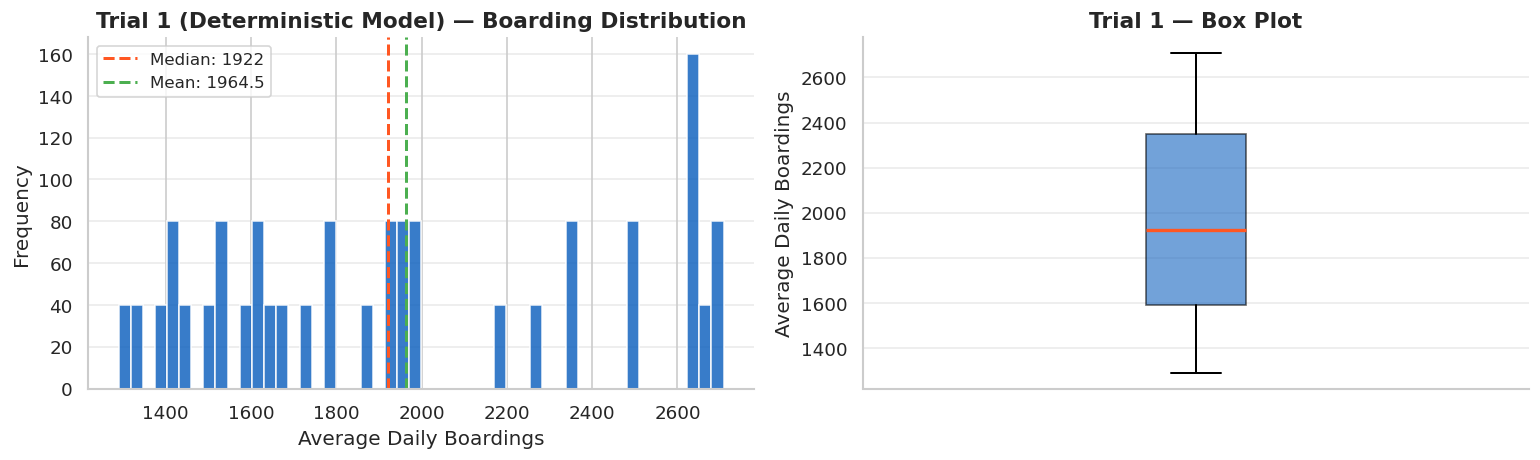

In [5]:
# Visualization: Trial 1 — Boarding Distribution

df = trials["Trial 1"]
vals = df["Average Daily Boardings"].dropna().values

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.hist(vals, bins=50, color="#1565C0", edgecolor="white", alpha=0.85)
ax.axvline(np.median(vals), color="#FF5722", linestyle="--", linewidth=1.8,
           label=f"Median: {np.median(vals):.0f}")
ax.axvline(vals.mean(), color="#4CAF50", linestyle="--", linewidth=1.8,
           label=f"Mean: {vals.mean():.1f}")
ax.set_title("Trial 1 (Deterministic Model) — Boarding Distribution", fontsize=13, fontweight="bold")
ax.set_xlabel("Average Daily Boardings")
ax.set_ylabel("Frequency")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.4)
sns.despine(ax=ax)

ax2 = axes[1]
ax2.boxplot(vals, vert=True, patch_artist=True,
            boxprops=dict(facecolor="#1565C0", alpha=0.6),
            medianprops=dict(color="#FF5722", linewidth=2),
            whiskerprops=dict(linewidth=1.2),
            capprops=dict(linewidth=1.2),
            flierprops=dict(marker=".", markersize=2, alpha=0.3))
ax2.set_title("Trial 1 — Box Plot", fontsize=13, fontweight="bold")
ax2.set_ylabel("Average Daily Boardings")
ax2.set_xticks([])
ax2.grid(axis="y", alpha=0.4)
sns.despine(ax=ax2)

plt.tight_layout()
plt.show()

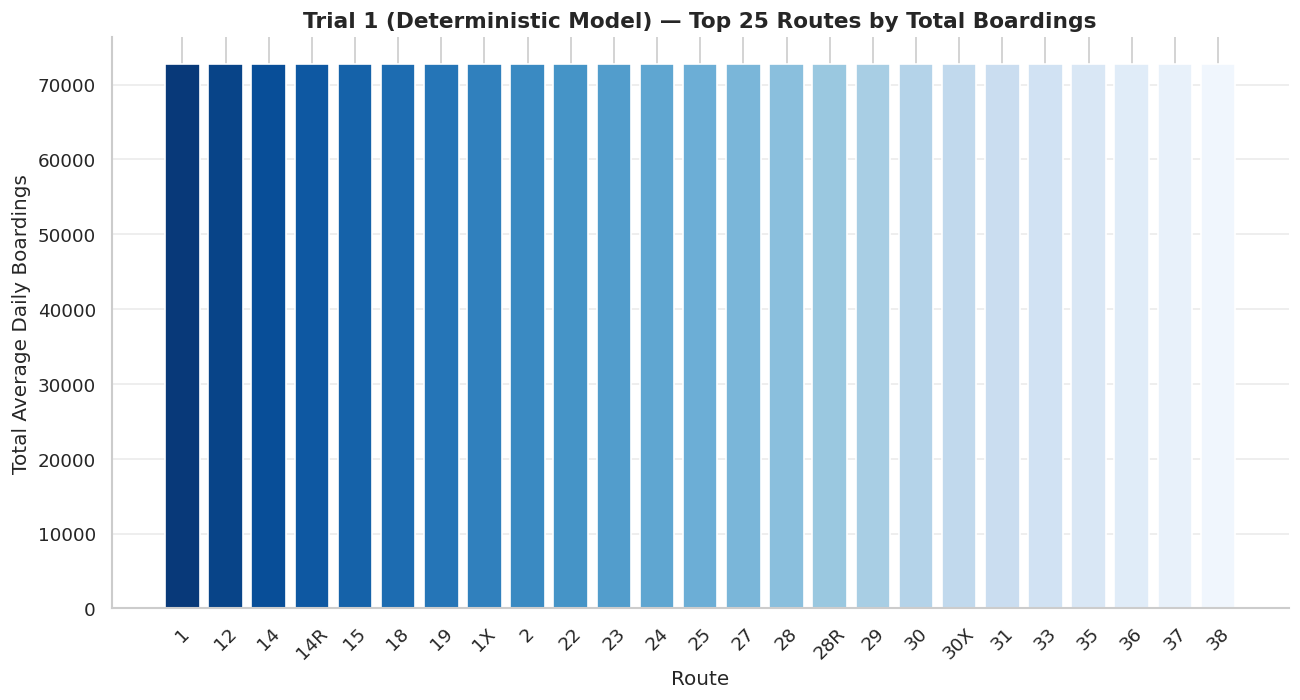

In [6]:
# Visualization: Trial 1 — Top 25 Routes by Total Boardings

df = trials["Trial 1"]
route_totals = df.groupby("Route")["Average Daily Boardings"].sum().sort_values(ascending=False).head(25)

fig, ax = plt.subplots(figsize=(11, 6))
palette = sns.color_palette("Blues_r", len(route_totals))
ax.bar(route_totals.index.astype(str), route_totals.values, color=palette, edgecolor="white")
ax.set_title("Trial 1 (Deterministic Model) — Top 25 Routes by Total Boardings", fontsize=13, fontweight="bold")
ax.set_xlabel("Route")
ax.set_ylabel("Total Average Daily Boardings")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()

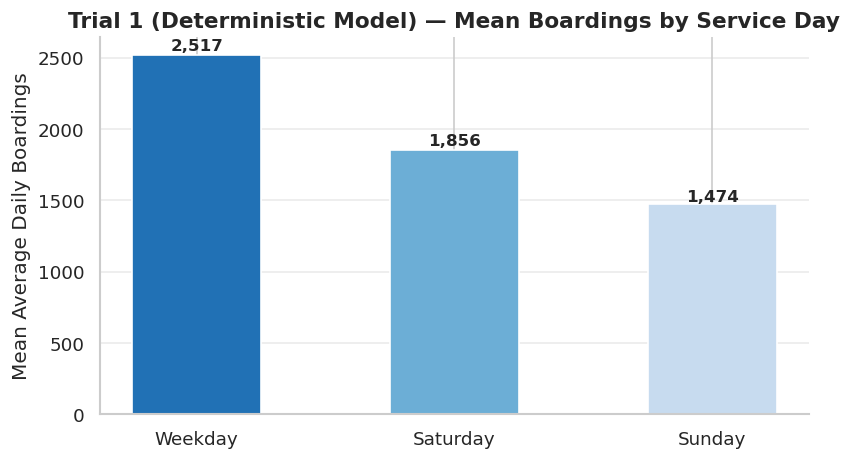

In [7]:
# Visualization: Trial 1 — Boardings by Service Day Type

df = trials["Trial 1"]

if "Service Day of the Week" in df.columns:
    day_avg = df.groupby("Service Day of the Week")["Average Daily Boardings"].mean().sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(7, 4))
    palette = sns.color_palette("Blues_r", len(day_avg))
    bars = ax.bar(day_avg.index, day_avg.values, color=palette, edgecolor="white", width=0.5)
    for bar, val in zip(bars, day_avg.values):
        ax.text(bar.get_x() + bar.get_width() / 2, val * 1.015,
                f"{val:,.0f}", ha="center", fontsize=10, fontweight="bold")
    ax.set_title("Trial 1 (Deterministic Model) — Mean Boardings by Service Day", fontsize=13, fontweight="bold")
    ax.set_ylabel("Mean Average Daily Boardings")
    ax.grid(axis="y", alpha=0.4)
    sns.despine()
    plt.tight_layout()
    plt.show()
else:
    print("No 'Service Day of the Week' column found.")

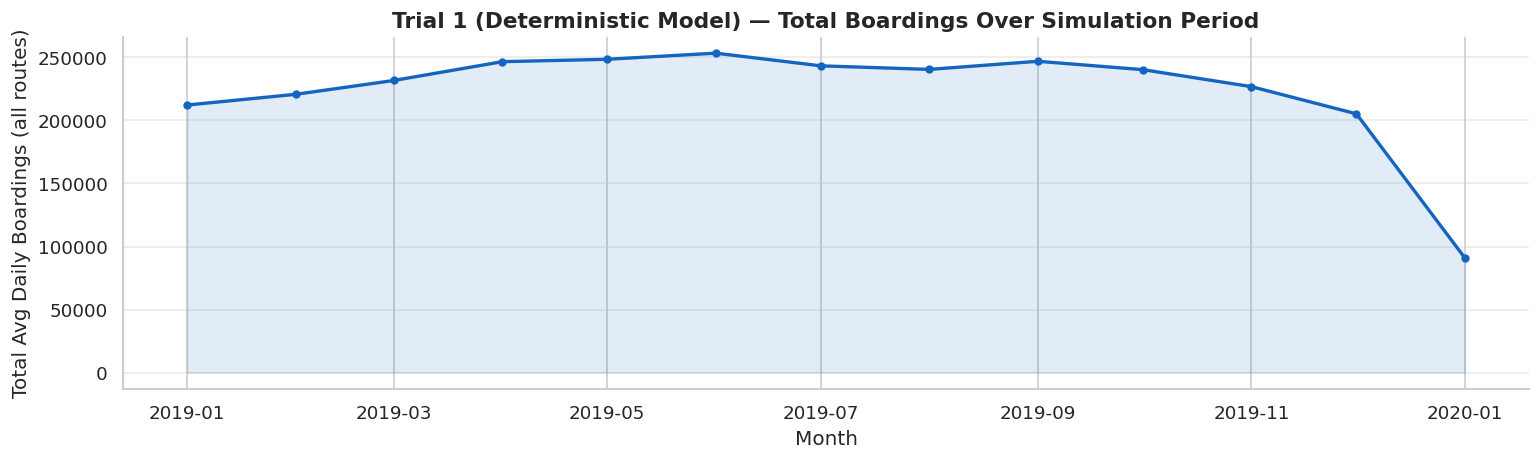

In [8]:
# Visualization: Trial 1 — Monthly Boardings Trend

df = trials["Trial 1"]

if "Month" in df.columns and df["Month"].notna().any():
    monthly = df.groupby("Month")["Average Daily Boardings"].sum().reset_index()

    fig, ax = plt.subplots(figsize=(13, 4))
    ax.plot(monthly["Month"], monthly["Average Daily Boardings"],
            color="#1565C0", linewidth=2, marker="o", markersize=4)
    ax.fill_between(monthly["Month"], monthly["Average Daily Boardings"],
                    alpha=0.12, color="#1565C0")
    ax.set_title("Trial 1 (Deterministic Model) — Total Boardings Over Simulation Period", fontsize=13, fontweight="bold")
    ax.set_xlabel("Month")
    ax.set_ylabel("Total Avg Daily Boardings (all routes)")
    ax.grid(axis="y", alpha=0.4)
    sns.despine()
    plt.tight_layout()
    plt.show()
else:
    print("No Month column available for trend plot.")

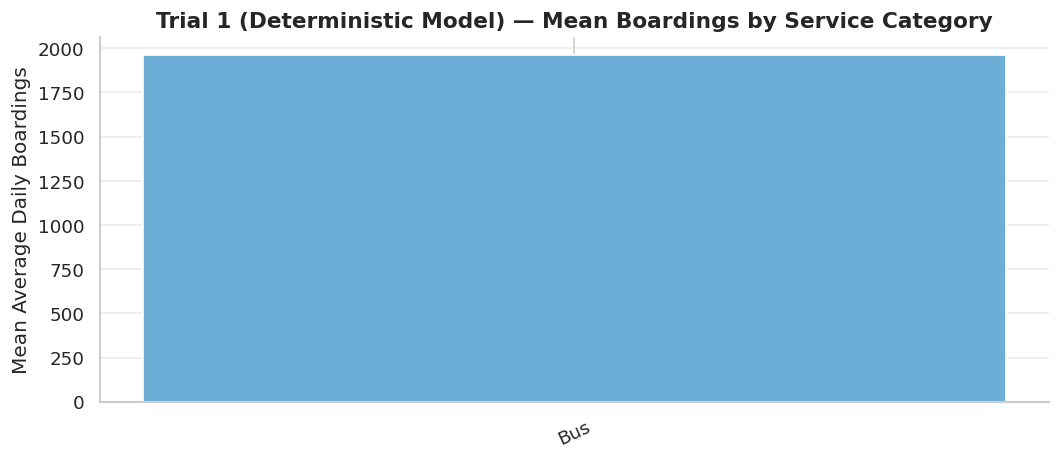

In [9]:
# Visualization: Trial 1 — Boardings by Service Category

df = trials["Trial 1"]

if "Service Category" in df.columns:
    cat_avg = df.groupby("Service Category")["Average Daily Boardings"].mean().sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(9, 4))
    palette = sns.color_palette("Blues_r", len(cat_avg))
    ax.bar(cat_avg.index, cat_avg.values, color=palette, edgecolor="white")
    ax.set_title("Trial 1 (Deterministic Model) — Mean Boardings by Service Category", fontsize=13, fontweight="bold")
    ax.set_ylabel("Mean Average Daily Boardings")
    ax.tick_params(axis="x", rotation=25)
    ax.grid(axis="y", alpha=0.4)
    sns.despine()
    plt.tight_layout()
    plt.show()
else:
    print("No 'Service Category' column found.")

---

## Trial 2 — High Fidelity Model
**Directory:** `trial_2`

In [10]:
# Trial 2 — Overview

t_name = "Trial 2"
df = trials[t_name]

print(f"{t_name} — {df.shape[0]:,} records  |  {df['Route'].nunique()} routes")
print(f"Columns      : {list(df.columns)}")
if "Month" in df.columns and df["Month"].notna().any():
    print(f"Date Range   : {df['Month'].min().strftime('%b %Y')} → {df['Month'].max().strftime('%b %Y')}")
if "Service Day of the Week" in df.columns:
    print(f"Day Types    : {sorted(df['Service Day of the Week'].dropna().unique())}")
if "Service Category" in df.columns:
    print(f"Categories   : {sorted(df['Service Category'].dropna().unique())}")

print()
print(df["Average Daily Boardings"].describe().round(1).to_string())

Trial 2 — 1,480 records  |  40 routes
Columns      : ['Month', 'Route', 'Service Category', 'Service Day of the Week', 'Average Daily Boardings']
Date Range   : Jan 2019 → Jan 2020
Day Types    : ['Saturday', 'Sunday', 'Weekday']
Categories   : ['Bus', 'Cable Car', 'Light Rail']

count    1480.0
mean     1984.5
std       514.4
min      1156.0
25%      1591.8
50%      1846.0
75%      2380.5
max      3130.0


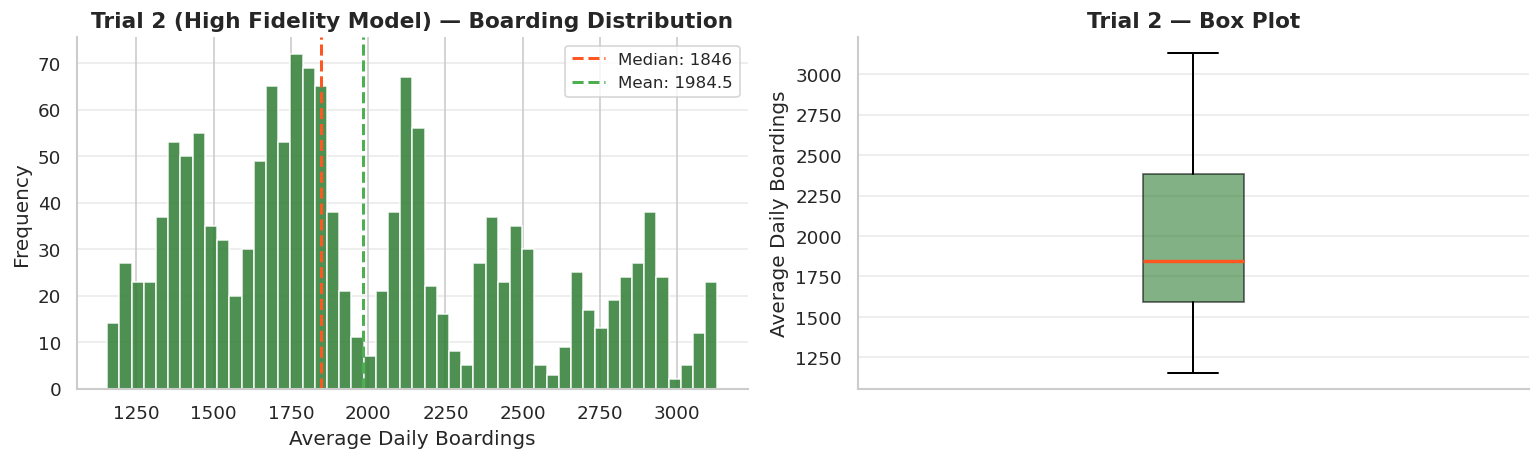

In [11]:
# Visualization: Trial 2 — Boarding Distribution

df = trials["Trial 2"]
vals = df["Average Daily Boardings"].dropna().values

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.hist(vals, bins=50, color="#2E7D32", edgecolor="white", alpha=0.85)
ax.axvline(np.median(vals), color="#FF5722", linestyle="--", linewidth=1.8,
           label=f"Median: {np.median(vals):.0f}")
ax.axvline(vals.mean(), color="#4CAF50", linestyle="--", linewidth=1.8,
           label=f"Mean: {vals.mean():.1f}")
ax.set_title("Trial 2 (High Fidelity Model) — Boarding Distribution", fontsize=13, fontweight="bold")
ax.set_xlabel("Average Daily Boardings")
ax.set_ylabel("Frequency")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.4)
sns.despine(ax=ax)

ax2 = axes[1]
ax2.boxplot(vals, vert=True, patch_artist=True,
            boxprops=dict(facecolor="#2E7D32", alpha=0.6),
            medianprops=dict(color="#FF5722", linewidth=2),
            whiskerprops=dict(linewidth=1.2),
            capprops=dict(linewidth=1.2),
            flierprops=dict(marker=".", markersize=2, alpha=0.3))
ax2.set_title("Trial 2 — Box Plot", fontsize=13, fontweight="bold")
ax2.set_ylabel("Average Daily Boardings")
ax2.set_xticks([])
ax2.grid(axis="y", alpha=0.4)
sns.despine(ax=ax2)

plt.tight_layout()
plt.show()

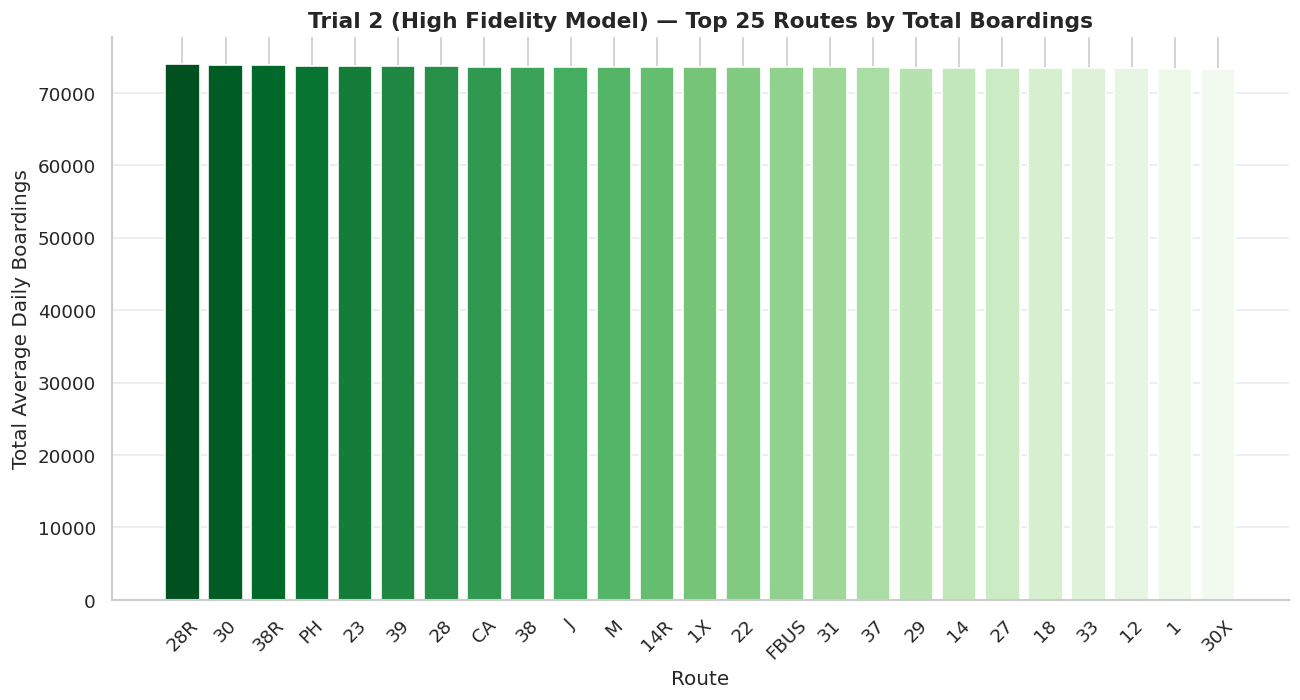

In [12]:
# Visualization: Trial 2 — Top 25 Routes by Total Boardings

df = trials["Trial 2"]
route_totals = df.groupby("Route")["Average Daily Boardings"].sum().sort_values(ascending=False).head(25)

fig, ax = plt.subplots(figsize=(11, 6))
palette = sns.color_palette("Greens_r", len(route_totals))
ax.bar(route_totals.index.astype(str), route_totals.values, color=palette, edgecolor="white")
ax.set_title("Trial 2 (High Fidelity Model) — Top 25 Routes by Total Boardings", fontsize=13, fontweight="bold")
ax.set_xlabel("Route")
ax.set_ylabel("Total Average Daily Boardings")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()

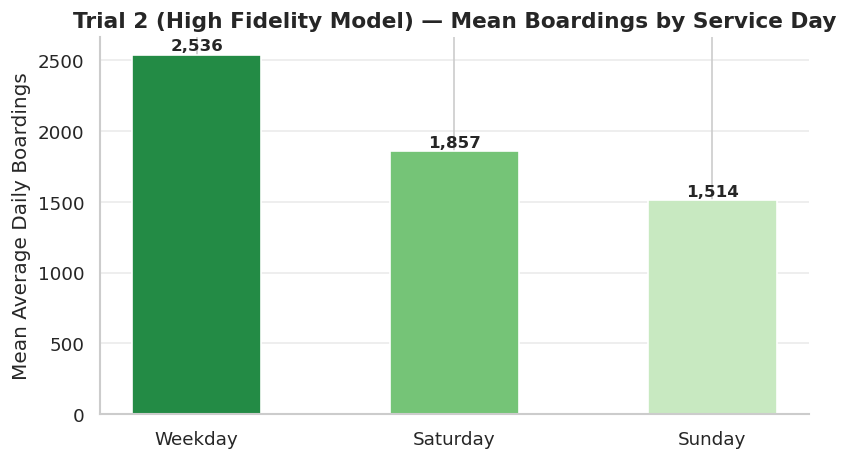

In [13]:
# Visualization: Trial 2 — Boardings by Service Day Type

df = trials["Trial 2"]

if "Service Day of the Week" in df.columns:
    day_avg = df.groupby("Service Day of the Week")["Average Daily Boardings"].mean().sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(7, 4))
    palette = sns.color_palette("Greens_r", len(day_avg))
    bars = ax.bar(day_avg.index, day_avg.values, color=palette, edgecolor="white", width=0.5)
    for bar, val in zip(bars, day_avg.values):
        ax.text(bar.get_x() + bar.get_width() / 2, val * 1.015,
                f"{val:,.0f}", ha="center", fontsize=10, fontweight="bold")
    ax.set_title("Trial 2 (High Fidelity Model) — Mean Boardings by Service Day", fontsize=13, fontweight="bold")
    ax.set_ylabel("Mean Average Daily Boardings")
    ax.grid(axis="y", alpha=0.4)
    sns.despine()
    plt.tight_layout()
    plt.show()
else:
    print("No 'Service Day of the Week' column found.")

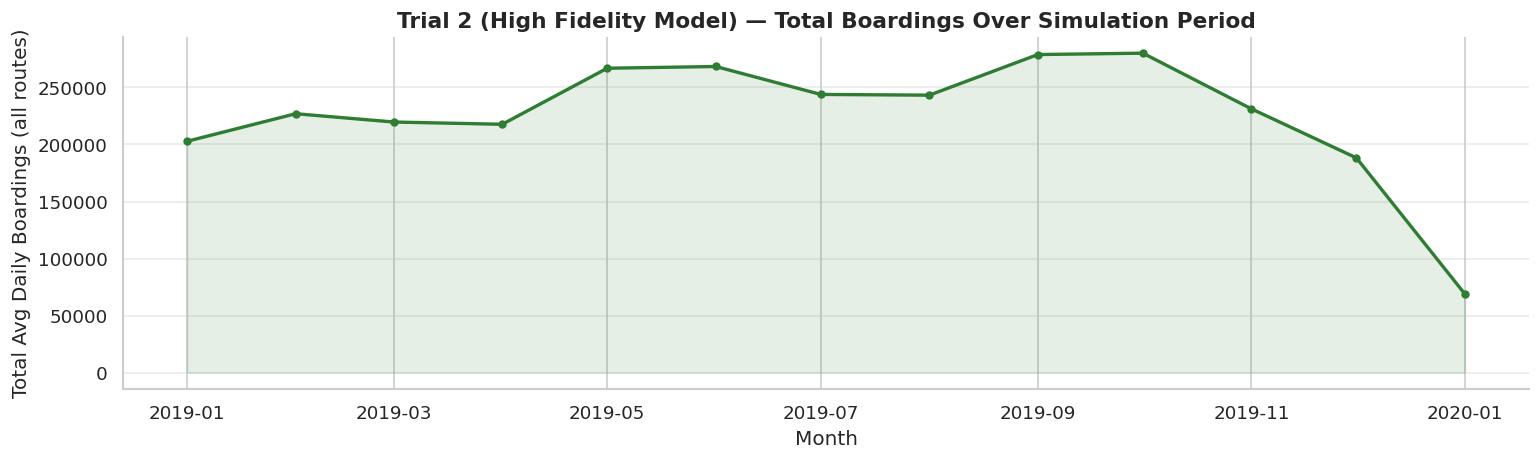

In [14]:
# Visualization: Trial 2 — Monthly Boardings Trend

df = trials["Trial 2"]

if "Month" in df.columns and df["Month"].notna().any():
    monthly = df.groupby("Month")["Average Daily Boardings"].sum().reset_index()

    fig, ax = plt.subplots(figsize=(13, 4))
    ax.plot(monthly["Month"], monthly["Average Daily Boardings"],
            color="#2E7D32", linewidth=2, marker="o", markersize=4)
    ax.fill_between(monthly["Month"], monthly["Average Daily Boardings"],
                    alpha=0.12, color="#2E7D32")
    ax.set_title("Trial 2 (High Fidelity Model) — Total Boardings Over Simulation Period", fontsize=13, fontweight="bold")
    ax.set_xlabel("Month")
    ax.set_ylabel("Total Avg Daily Boardings (all routes)")
    ax.grid(axis="y", alpha=0.4)
    sns.despine()
    plt.tight_layout()
    plt.show()
else:
    print("No Month column available for trend plot.")

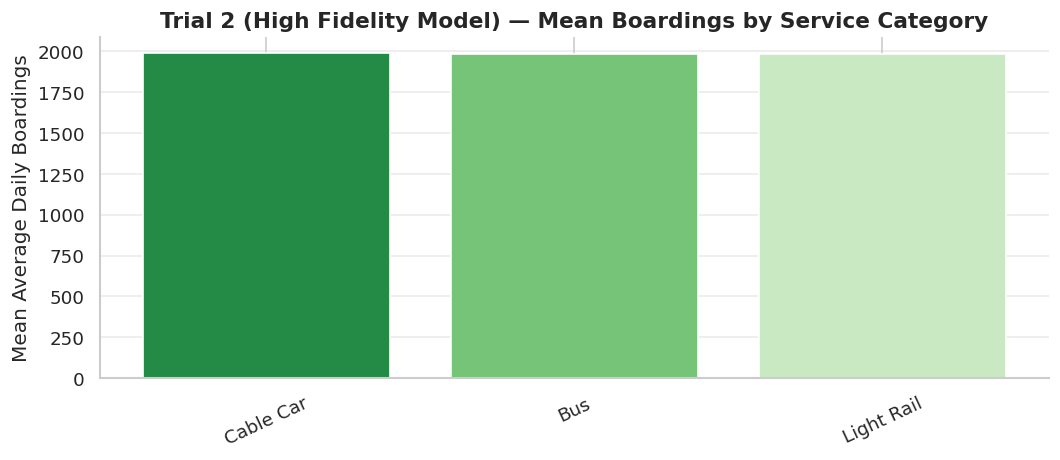

In [15]:
# Visualization: Trial 2 — Boardings by Service Category

df = trials["Trial 2"]

if "Service Category" in df.columns:
    cat_avg = df.groupby("Service Category")["Average Daily Boardings"].mean().sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(9, 4))
    palette = sns.color_palette("Greens_r", len(cat_avg))
    ax.bar(cat_avg.index, cat_avg.values, color=palette, edgecolor="white")
    ax.set_title("Trial 2 (High Fidelity Model) — Mean Boardings by Service Category", fontsize=13, fontweight="bold")
    ax.set_ylabel("Mean Average Daily Boardings")
    ax.tick_params(axis="x", rotation=25)
    ax.grid(axis="y", alpha=0.4)
    sns.despine()
    plt.tight_layout()
    plt.show()
else:
    print("No 'Service Category' column found.")

---

## Trial 3 — Rule Based Model
**Directory:** `trial_3`

In [16]:
# Trial 3 — Overview

t_name = "Trial 3"
df = trials[t_name]

print(f"{t_name} — {df.shape[0]:,} records  |  {df['Route'].nunique()} routes")
print(f"Columns      : {list(df.columns)}")
if "Month" in df.columns and df["Month"].notna().any():
    print(f"Date Range   : {df['Month'].min().strftime('%b %Y')} → {df['Month'].max().strftime('%b %Y')}")
if "Service Day of the Week" in df.columns:
    print(f"Day Types    : {sorted(df['Service Day of the Week'].dropna().unique())}")
if "Service Category" in df.columns:
    print(f"Categories   : {sorted(df['Service Category'].dropna().unique())}")

print()
print(df["Average Daily Boardings"].describe().round(1).to_string())

Trial 3 — 1,480 records  |  40 routes
Columns      : ['Month', 'Route', 'Service Category', 'Service Day of the Week', 'Average Daily Boardings']
Date Range   : Jan 2019 → Jan 2020
Day Types    : ['Saturday', 'Sunday', 'Weekday']
Categories   : ['Bus', 'Cable Car', 'Light Rail']

count    1480.0
mean      697.8
std       112.7
min       516.0
25%       612.0
50%       678.0
75%       765.0
max      1101.0


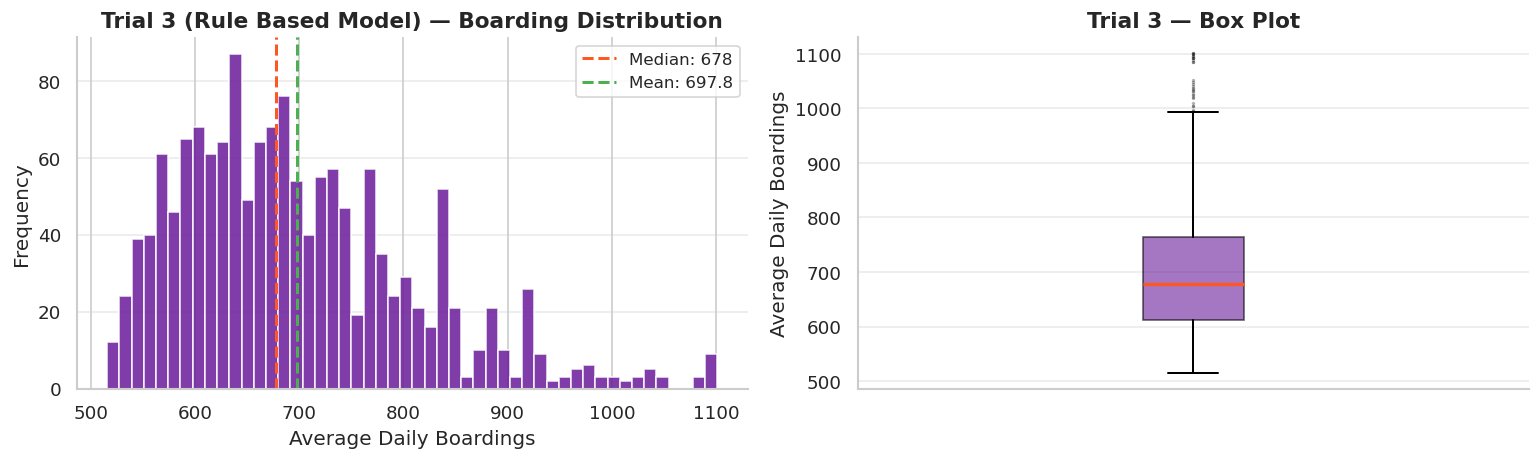

In [17]:
# Visualization: Trial 3 — Boarding Distribution

df = trials["Trial 3"]
vals = df["Average Daily Boardings"].dropna().values

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.hist(vals, bins=50, color="#6A1B9A", edgecolor="white", alpha=0.85)
ax.axvline(np.median(vals), color="#FF5722", linestyle="--", linewidth=1.8,
           label=f"Median: {np.median(vals):.0f}")
ax.axvline(vals.mean(), color="#4CAF50", linestyle="--", linewidth=1.8,
           label=f"Mean: {vals.mean():.1f}")
ax.set_title("Trial 3 (Rule Based Model) — Boarding Distribution", fontsize=13, fontweight="bold")
ax.set_xlabel("Average Daily Boardings")
ax.set_ylabel("Frequency")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.4)
sns.despine(ax=ax)

ax2 = axes[1]
ax2.boxplot(vals, vert=True, patch_artist=True,
            boxprops=dict(facecolor="#6A1B9A", alpha=0.6),
            medianprops=dict(color="#FF5722", linewidth=2),
            whiskerprops=dict(linewidth=1.2),
            capprops=dict(linewidth=1.2),
            flierprops=dict(marker=".", markersize=2, alpha=0.3))
ax2.set_title("Trial 3 — Box Plot", fontsize=13, fontweight="bold")
ax2.set_ylabel("Average Daily Boardings")
ax2.set_xticks([])
ax2.grid(axis="y", alpha=0.4)
sns.despine(ax=ax2)

plt.tight_layout()
plt.show()

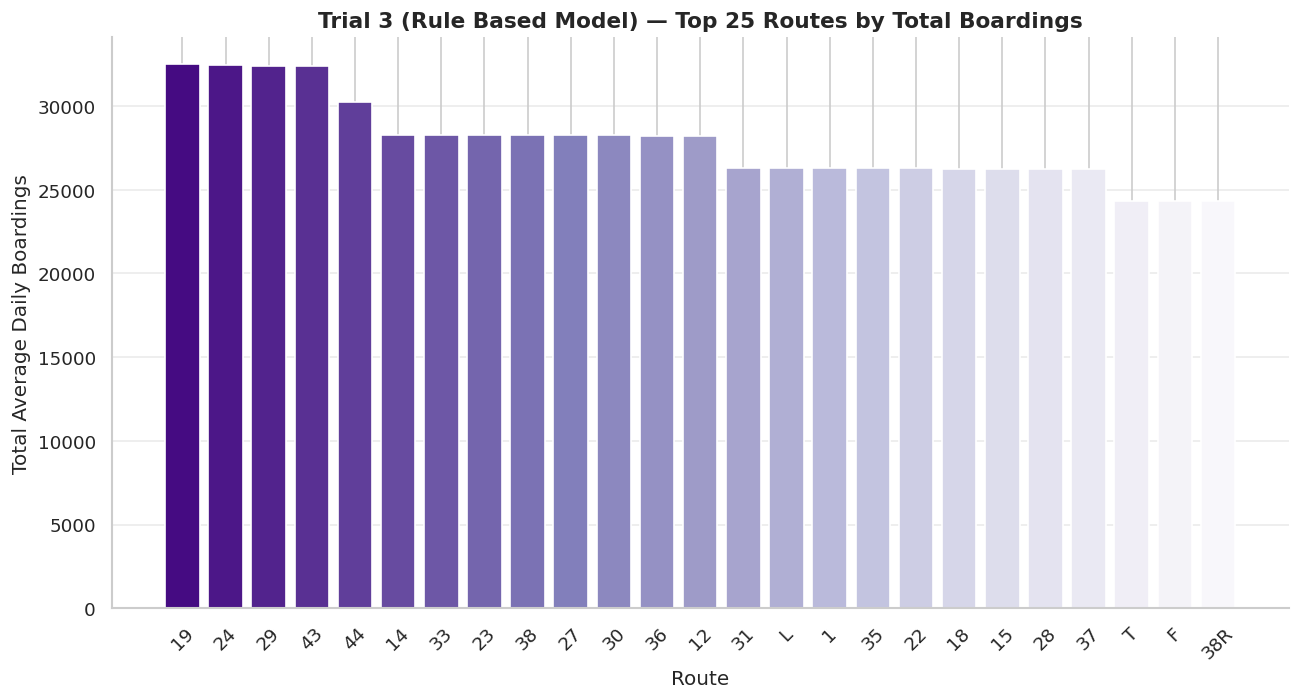

In [18]:
# Visualization: Trial 3 — Top 25 Routes by Total Boardings

df = trials["Trial 3"]
route_totals = df.groupby("Route")["Average Daily Boardings"].sum().sort_values(ascending=False).head(25)

fig, ax = plt.subplots(figsize=(11, 6))
palette = sns.color_palette("Purples_r", len(route_totals))
ax.bar(route_totals.index.astype(str), route_totals.values, color=palette, edgecolor="white")
ax.set_title("Trial 3 (Rule Based Model) — Top 25 Routes by Total Boardings", fontsize=13, fontweight="bold")
ax.set_xlabel("Route")
ax.set_ylabel("Total Average Daily Boardings")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()

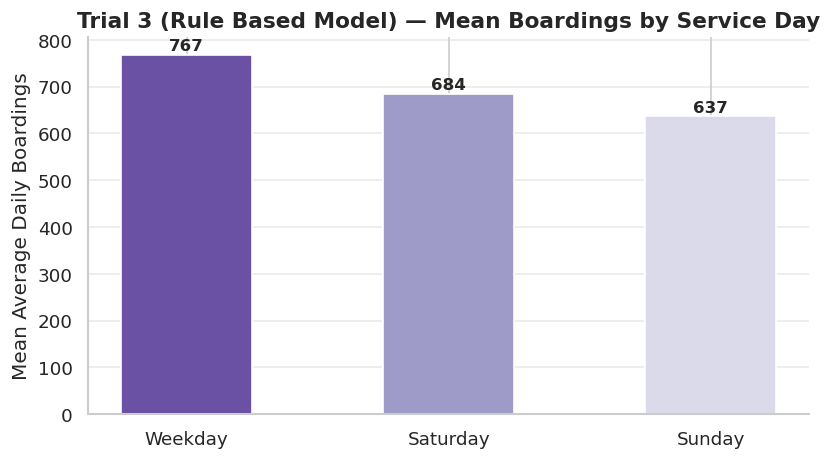

In [19]:
# Visualization: Trial 3 — Boardings by Service Day Type

df = trials["Trial 3"]

if "Service Day of the Week" in df.columns:
    day_avg = df.groupby("Service Day of the Week")["Average Daily Boardings"].mean().sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(7, 4))
    palette = sns.color_palette("Purples_r", len(day_avg))
    bars = ax.bar(day_avg.index, day_avg.values, color=palette, edgecolor="white", width=0.5)
    for bar, val in zip(bars, day_avg.values):
        ax.text(bar.get_x() + bar.get_width() / 2, val * 1.015,
                f"{val:,.0f}", ha="center", fontsize=10, fontweight="bold")
    ax.set_title("Trial 3 (Rule Based Model) — Mean Boardings by Service Day", fontsize=13, fontweight="bold")
    ax.set_ylabel("Mean Average Daily Boardings")
    ax.grid(axis="y", alpha=0.4)
    sns.despine()
    plt.tight_layout()
    plt.show()
else:
    print("No 'Service Day of the Week' column found.")

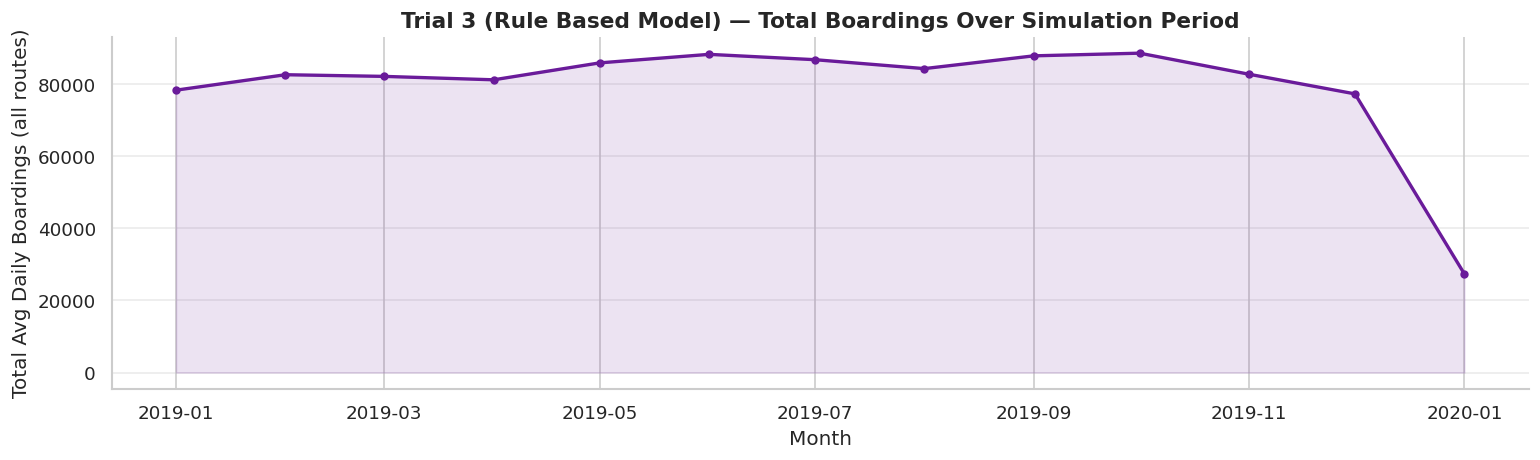

In [20]:
# Visualization: Trial 3 — Monthly Boardings Trend

df = trials["Trial 3"]

if "Month" in df.columns and df["Month"].notna().any():
    monthly = df.groupby("Month")["Average Daily Boardings"].sum().reset_index()

    fig, ax = plt.subplots(figsize=(13, 4))
    ax.plot(monthly["Month"], monthly["Average Daily Boardings"],
            color="#6A1B9A", linewidth=2, marker="o", markersize=4)
    ax.fill_between(monthly["Month"], monthly["Average Daily Boardings"],
                    alpha=0.12, color="#6A1B9A")
    ax.set_title("Trial 3 (Rule Based Model) — Total Boardings Over Simulation Period", fontsize=13, fontweight="bold")
    ax.set_xlabel("Month")
    ax.set_ylabel("Total Avg Daily Boardings (all routes)")
    ax.grid(axis="y", alpha=0.4)
    sns.despine()
    plt.tight_layout()
    plt.show()
else:
    print("No Month column available for trend plot.")

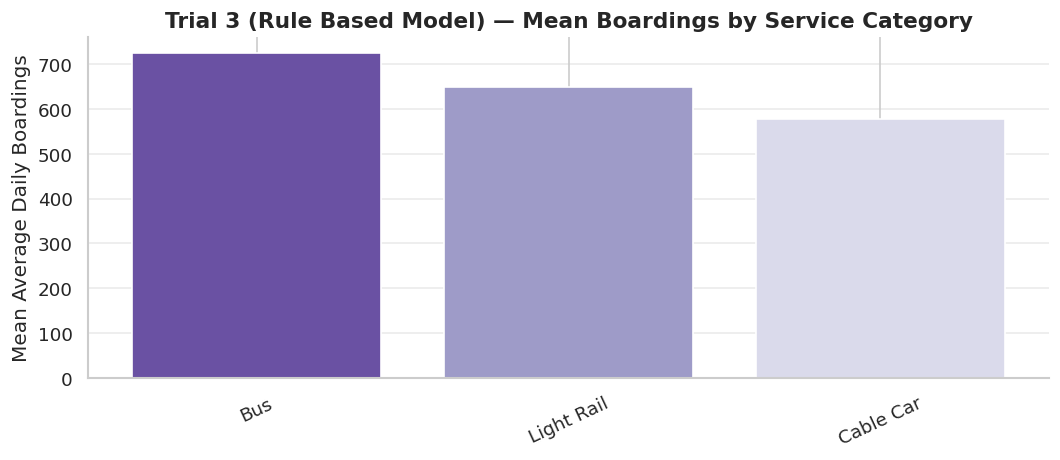

In [21]:
# Visualization: Trial 3 — Boardings by Service Category

df = trials["Trial 3"]

if "Service Category" in df.columns:
    cat_avg = df.groupby("Service Category")["Average Daily Boardings"].mean().sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(9, 4))
    palette = sns.color_palette("Purples_r", len(cat_avg))
    ax.bar(cat_avg.index, cat_avg.values, color=palette, edgecolor="white")
    ax.set_title("Trial 3 (Rule Based Model) — Mean Boardings by Service Category", fontsize=13, fontweight="bold")
    ax.set_ylabel("Mean Average Daily Boardings")
    ax.tick_params(axis="x", rotation=25)
    ax.grid(axis="y", alpha=0.4)
    sns.despine()
    plt.tight_layout()
    plt.show()
else:
    print("No 'Service Category' column found.")

---

## Trial 4 — Rule Based Model
**Directory:** `trial_4`

In [22]:
# Trial 4 — Overview

t_name = "Trial 4"
df = trials[t_name]

print(f"{t_name} — {df.shape[0]:,} records  |  {df['Route'].nunique()} routes")
print(f"Columns      : {list(df.columns)}")
if "Month" in df.columns and df["Month"].notna().any():
    print(f"Date Range   : {df['Month'].min().strftime('%b %Y')} → {df['Month'].max().strftime('%b %Y')}")
if "Service Day of the Week" in df.columns:
    print(f"Day Types    : {sorted(df['Service Day of the Week'].dropna().unique())}")
if "Service Category" in df.columns:
    print(f"Categories   : {sorted(df['Service Category'].dropna().unique())}")

print()
print(df["Average Daily Boardings"].describe().round(1).to_string())

Trial 4 — 1,480 records  |  40 routes
Columns      : ['Month', 'Route', 'Service Category', 'Service Day of the Week', 'Average Daily Boardings']
Date Range   : Jan 2019 → Jan 2020
Day Types    : ['Saturday', 'Sunday', 'Weekday']
Categories   : ['Bus', 'Cable Car', 'Light Rail']

count    1480.0
mean      696.8
std       111.0
min       513.0
25%       614.0
50%       675.5
75%       766.0
max      1110.0


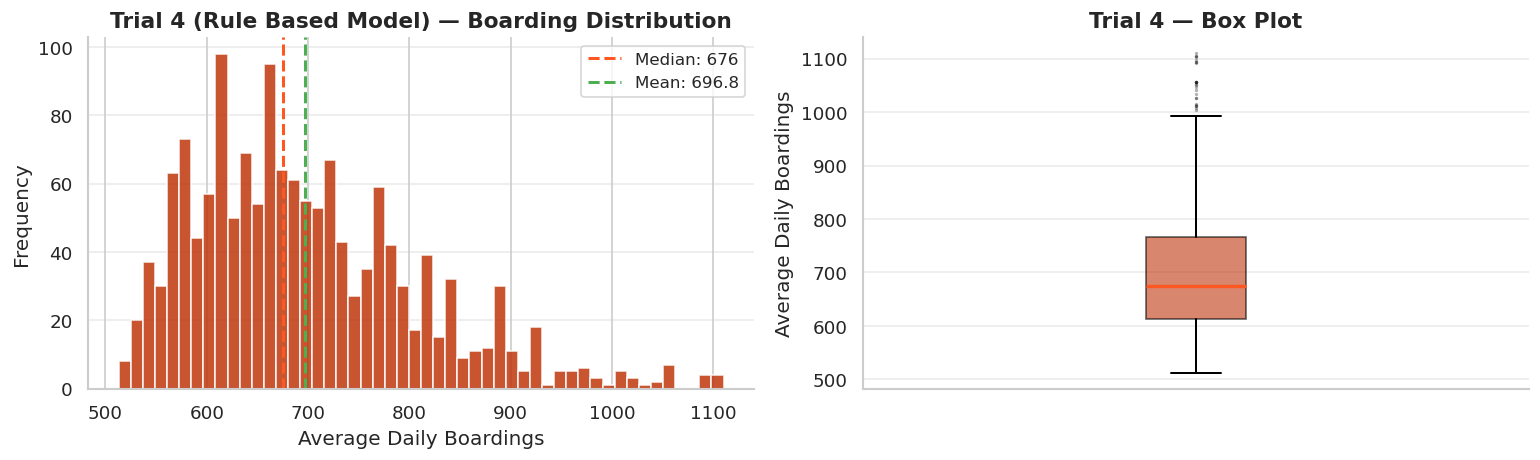

In [23]:
# Visualization: Trial 4 — Boarding Distribution

df = trials["Trial 4"]
vals = df["Average Daily Boardings"].dropna().values

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.hist(vals, bins=50, color="#BF360C", edgecolor="white", alpha=0.85)
ax.axvline(np.median(vals), color="#FF5722", linestyle="--", linewidth=1.8,
           label=f"Median: {np.median(vals):.0f}")
ax.axvline(vals.mean(), color="#4CAF50", linestyle="--", linewidth=1.8,
           label=f"Mean: {vals.mean():.1f}")
ax.set_title("Trial 4 (Rule Based Model) — Boarding Distribution", fontsize=13, fontweight="bold")
ax.set_xlabel("Average Daily Boardings")
ax.set_ylabel("Frequency")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.4)
sns.despine(ax=ax)

ax2 = axes[1]
ax2.boxplot(vals, vert=True, patch_artist=True,
            boxprops=dict(facecolor="#BF360C", alpha=0.6),
            medianprops=dict(color="#FF5722", linewidth=2),
            whiskerprops=dict(linewidth=1.2),
            capprops=dict(linewidth=1.2),
            flierprops=dict(marker=".", markersize=2, alpha=0.3))
ax2.set_title("Trial 4 — Box Plot", fontsize=13, fontweight="bold")
ax2.set_ylabel("Average Daily Boardings")
ax2.set_xticks([])
ax2.grid(axis="y", alpha=0.4)
sns.despine(ax=ax2)

plt.tight_layout()
plt.show()

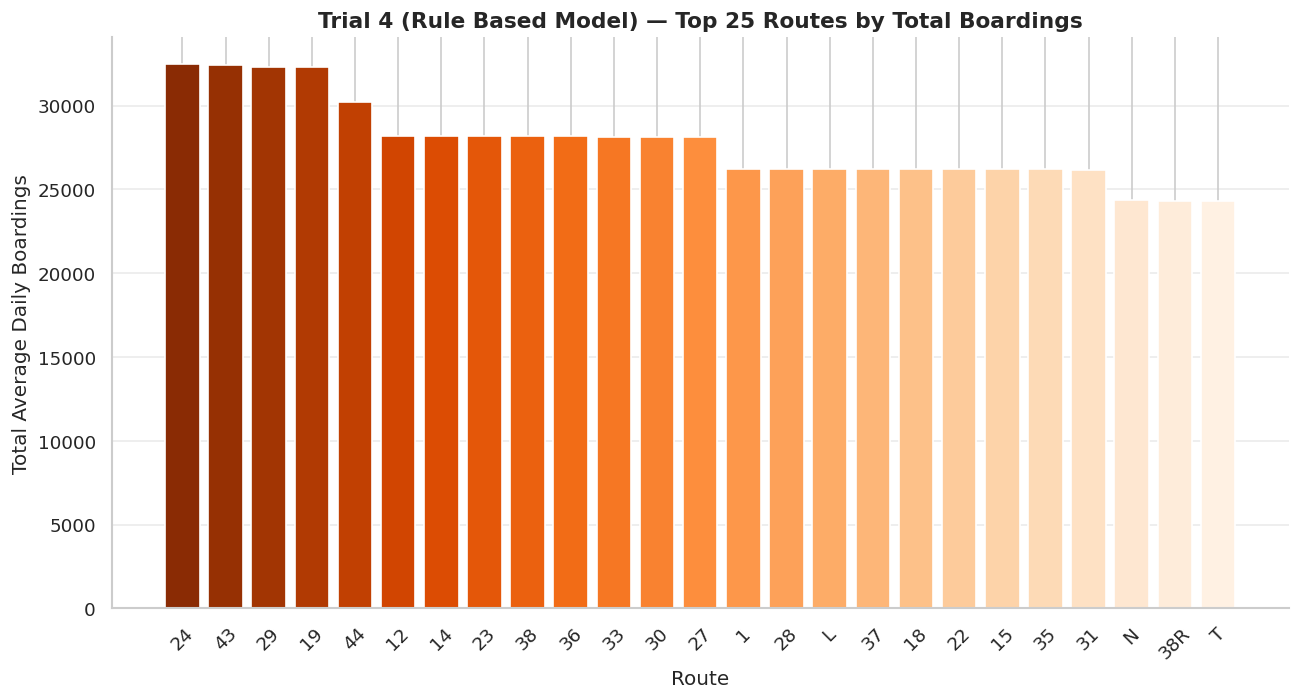

In [24]:
# Visualization: Trial 4 — Top 25 Routes by Total Boardings

df = trials["Trial 4"]
route_totals = df.groupby("Route")["Average Daily Boardings"].sum().sort_values(ascending=False).head(25)

fig, ax = plt.subplots(figsize=(11, 6))
palette = sns.color_palette("Oranges_r", len(route_totals))
ax.bar(route_totals.index.astype(str), route_totals.values, color=palette, edgecolor="white")
ax.set_title("Trial 4 (Rule Based Model) — Top 25 Routes by Total Boardings", fontsize=13, fontweight="bold")
ax.set_xlabel("Route")
ax.set_ylabel("Total Average Daily Boardings")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()

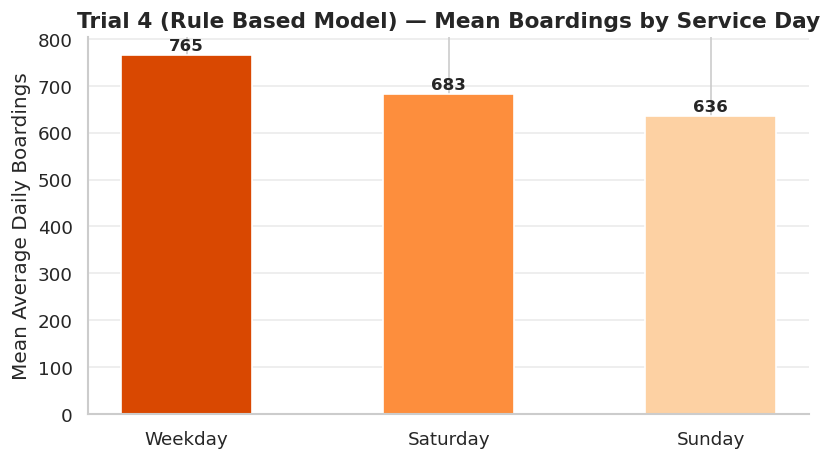

In [25]:
# Visualization: Trial 4 — Boardings by Service Day Type

df = trials["Trial 4"]

if "Service Day of the Week" in df.columns:
    day_avg = df.groupby("Service Day of the Week")["Average Daily Boardings"].mean().sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(7, 4))
    palette = sns.color_palette("Oranges_r", len(day_avg))
    bars = ax.bar(day_avg.index, day_avg.values, color=palette, edgecolor="white", width=0.5)
    for bar, val in zip(bars, day_avg.values):
        ax.text(bar.get_x() + bar.get_width() / 2, val * 1.015,
                f"{val:,.0f}", ha="center", fontsize=10, fontweight="bold")
    ax.set_title("Trial 4 (Rule Based Model) — Mean Boardings by Service Day", fontsize=13, fontweight="bold")
    ax.set_ylabel("Mean Average Daily Boardings")
    ax.grid(axis="y", alpha=0.4)
    sns.despine()
    plt.tight_layout()
    plt.show()
else:
    print("No 'Service Day of the Week' column found.")

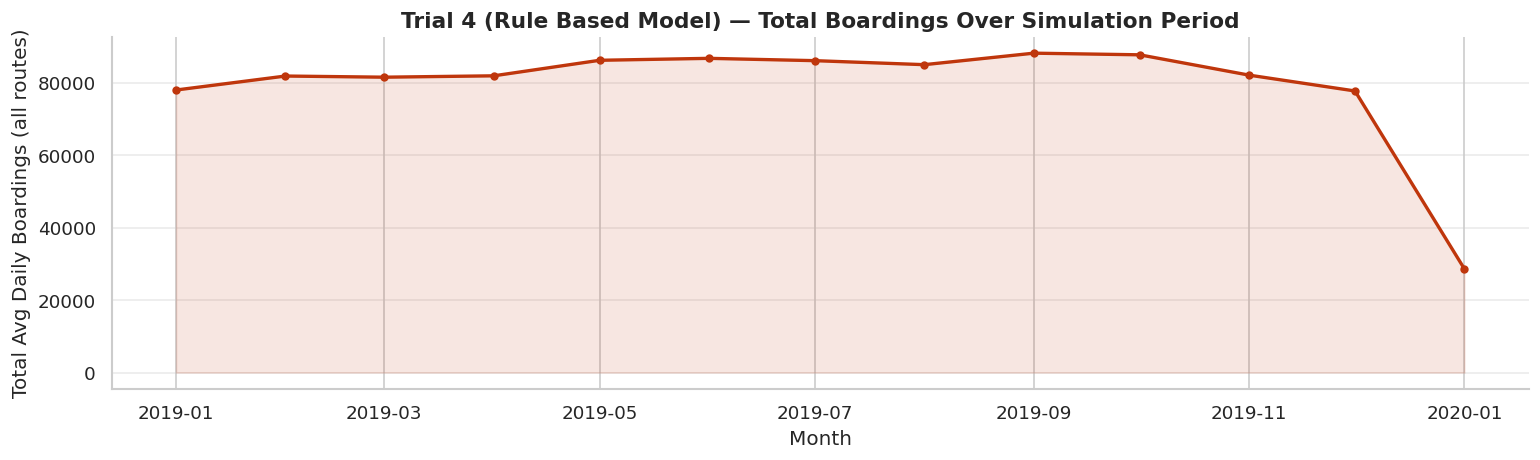

In [26]:
# Visualization: Trial 4 — Monthly Boardings Trend

df = trials["Trial 4"]

if "Month" in df.columns and df["Month"].notna().any():
    monthly = df.groupby("Month")["Average Daily Boardings"].sum().reset_index()

    fig, ax = plt.subplots(figsize=(13, 4))
    ax.plot(monthly["Month"], monthly["Average Daily Boardings"],
            color="#BF360C", linewidth=2, marker="o", markersize=4)
    ax.fill_between(monthly["Month"], monthly["Average Daily Boardings"],
                    alpha=0.12, color="#BF360C")
    ax.set_title("Trial 4 (Rule Based Model) — Total Boardings Over Simulation Period", fontsize=13, fontweight="bold")
    ax.set_xlabel("Month")
    ax.set_ylabel("Total Avg Daily Boardings (all routes)")
    ax.grid(axis="y", alpha=0.4)
    sns.despine()
    plt.tight_layout()
    plt.show()
else:
    print("No Month column available for trend plot.")

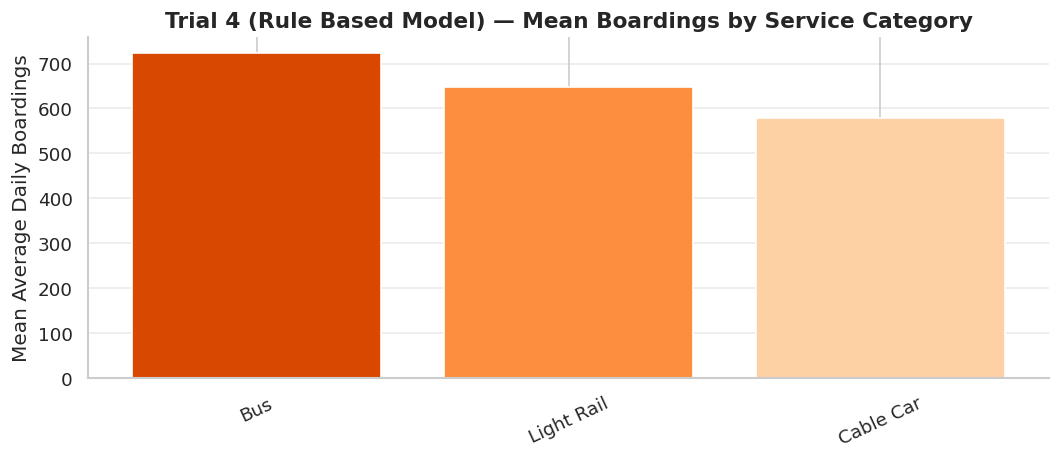

In [27]:
# Visualization: Trial 4 — Boardings by Service Category

df = trials["Trial 4"]

if "Service Category" in df.columns:
    cat_avg = df.groupby("Service Category")["Average Daily Boardings"].mean().sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(9, 4))
    palette = sns.color_palette("Oranges_r", len(cat_avg))
    ax.bar(cat_avg.index, cat_avg.values, color=palette, edgecolor="white")
    ax.set_title("Trial 4 (Rule Based Model) — Mean Boardings by Service Category", fontsize=13, fontweight="bold")
    ax.set_ylabel("Mean Average Daily Boardings")
    ax.tick_params(axis="x", rotation=25)
    ax.grid(axis="y", alpha=0.4)
    sns.despine()
    plt.tight_layout()
    plt.show()
else:
    print("No 'Service Category' column found.")

---

## Comparative Evaluation — All Trials

**Description:** This section brings all four trials together for a unified evaluation against one another and against the empirical SFMTA ridership baseline. The analysis covers cross-trial volume comparisons, route-level rank correlation matrices, temporal alignment, error heatmaps, and a summary performance table.

In [28]:
# Build cross-trial route boarding table
# Align all trials and the empirical baseline on a common route index.

trial_route_series = {}
for t_name, df in trials.items():
    if not df.empty:
        trial_route_series[t_name] = df.groupby("Route")["Average Daily Boardings"].sum()

empirical_series = empirical_by_route.copy()
empirical_series.index = empirical_series.index.astype(str)

all_series = {**trial_route_series, "Empirical": empirical_series}
combined_df = pd.DataFrame(all_series).fillna(0)

print("Cross-Trial Route Table")
print(f"  Routes in combined index  : {len(combined_df)}")
print(f"  Columns                   : {list(combined_df.columns)}")
print()
print(combined_df.describe().round(1).to_string())

Cross-Trial Route Table
  Routes in combined index  : 108
  Columns                   : ['Trial 1', 'Trial 2', 'Trial 3', 'Trial 4', 'Empirical']

       Trial 1  Trial 2  Trial 3  Trial 4  Empirical
count    108.0    108.0    108.0    108.0      108.0
mean   26921.1  27195.2   9562.5   9548.2    11173.1
std    35264.5  35623.9  12688.9  12668.8    18993.0
min        0.0      0.0      0.0      0.0        0.0
25%        0.0      0.0      0.0      0.0        0.0
50%        0.0      0.0      0.0      0.0      800.0
75%    72687.0  73263.8  24311.0  24292.2    13950.0
max    72687.0  73983.0  32487.0  32464.0    85100.0


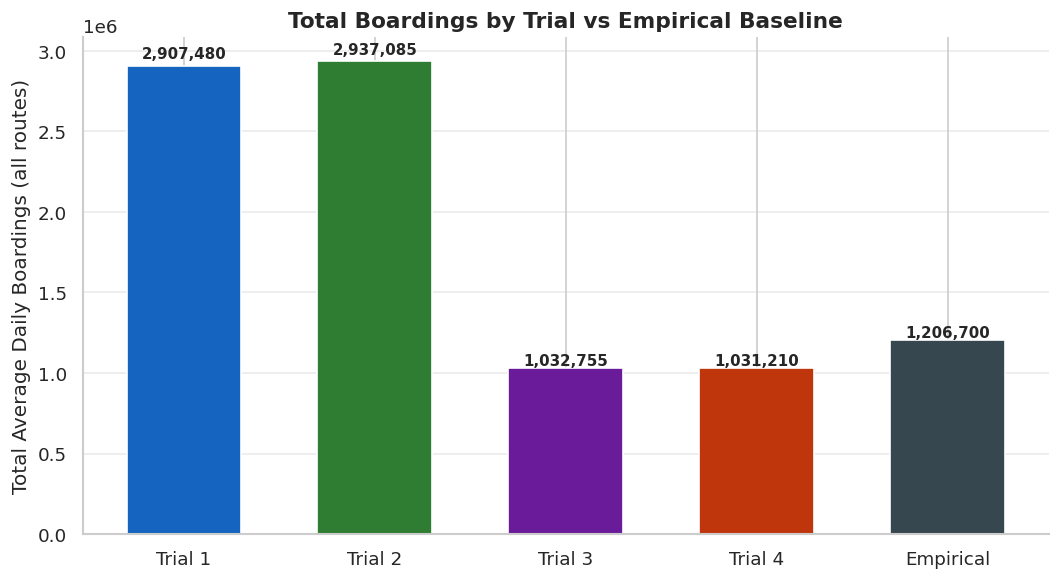

In [29]:
# Visualization: Total Boarding Volume by Trial vs Empirical

totals  = combined_df.sum()
colors_bar = ["#1565C0", "#2E7D32", "#6A1B9A", "#BF360C", "#37474F"]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(totals.index, totals.values, color=colors_bar[:len(totals)], edgecolor="white", width=0.6)
for bar, val in zip(bars, totals.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val * 1.015,
            f"{val:,.0f}", ha="center", fontsize=9, fontweight="bold")
ax.set_title("Total Boardings by Trial vs Empirical Baseline", fontsize=13, fontweight="bold")
ax.set_ylabel("Total Average Daily Boardings (all routes)")
ax.grid(axis="y", alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()

In [30]:
# Top 20 empirical routes — used as shared reference throughout this section
top20_routes = empirical_series.sort_values(ascending=False).head(20).index

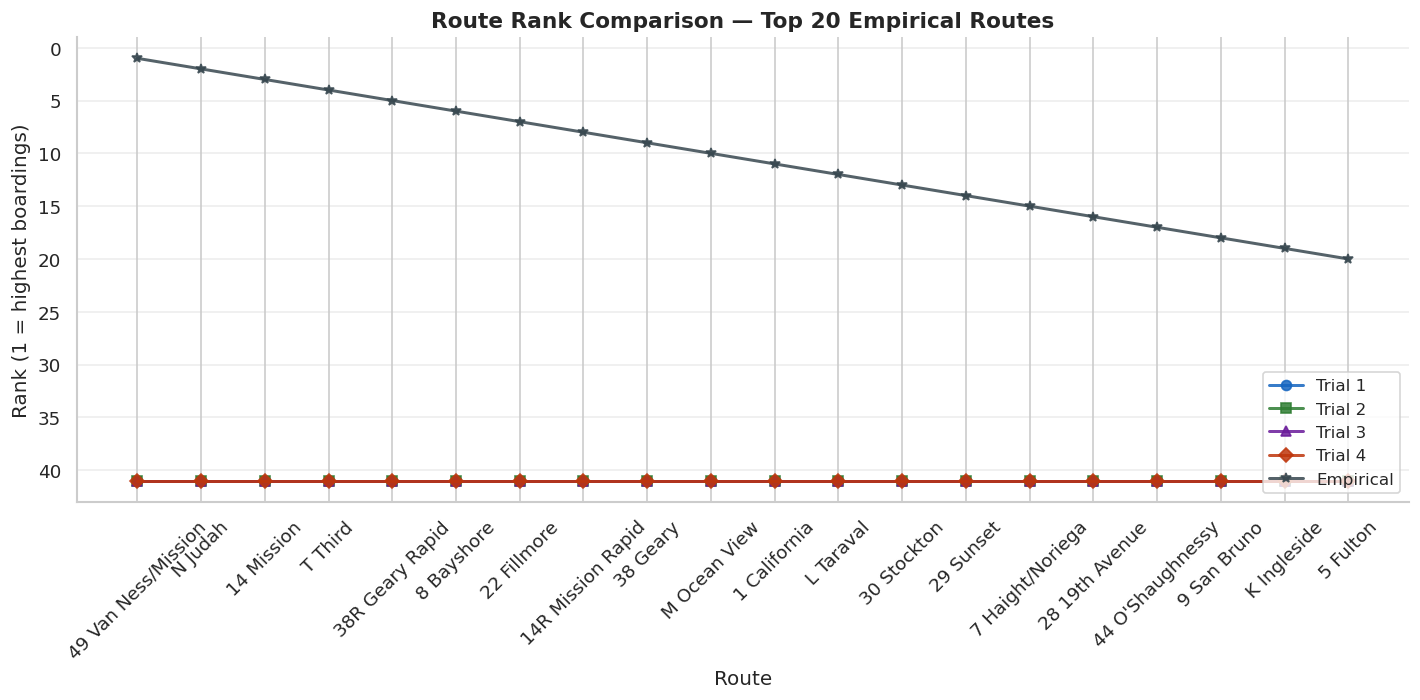

In [31]:
# Visualization: Route Rank Chart — Top 20 Empirical Routes

rank_df     = combined_df.rank(ascending=False, method="min")
rank_subset = rank_df.loc[top20_routes]

colors_r = ["#1565C0", "#2E7D32", "#6A1B9A", "#BF360C", "#37474F"]
markers  = ["o", "s", "^", "D", "*"]

fig, ax = plt.subplots(figsize=(12, 6))
for i, col in enumerate(rank_subset.columns):
    ax.plot(rank_subset.index.astype(str), rank_subset[col],
            marker=markers[i % len(markers)], linewidth=1.8,
            color=colors_r[i % len(colors_r)], label=col, alpha=0.85)
ax.invert_yaxis()
ax.set_title("Route Rank Comparison — Top 20 Empirical Routes", fontsize=13, fontweight="bold")
ax.set_xlabel("Route")
ax.set_ylabel("Rank (1 = highest boardings)")
ax.tick_params(axis="x", rotation=45)
ax.legend(fontsize=10, loc="lower right")
ax.grid(axis="y", alpha=0.35)
sns.despine()
plt.tight_layout()
plt.show()

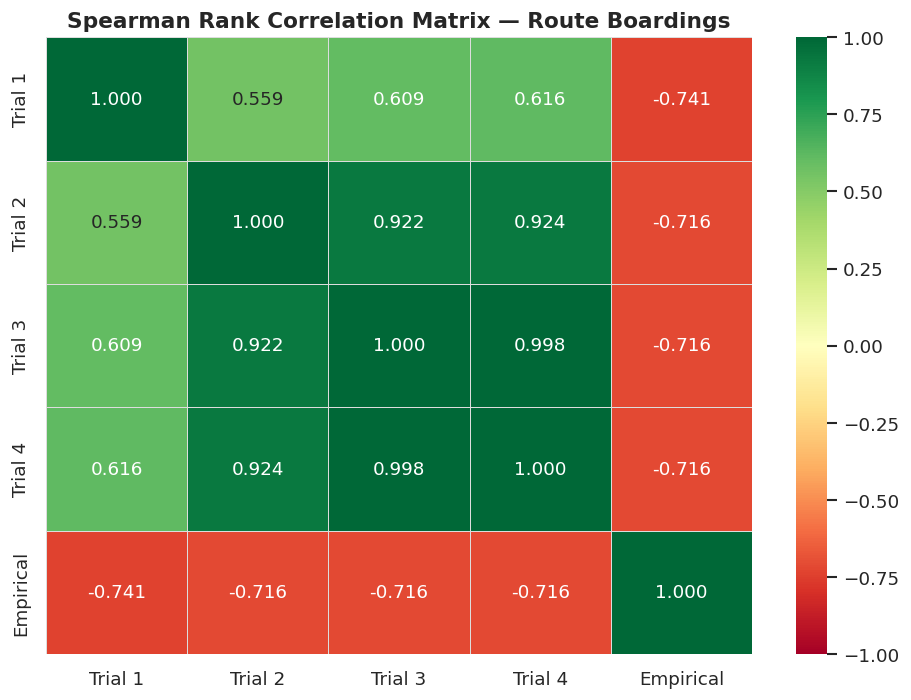

In [32]:
# Visualization: Spearman Rank Correlation Matrix

cols        = list(combined_df.columns)
corr_matrix = combined_df[cols].corr(method="spearman")

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True, fmt=".3f",
    cmap="RdYlGn",
    vmin=-1, vmax=1,
    linewidths=0.5, linecolor="#ddd",
    ax=ax,
    annot_kws={"fontsize": 11}
)
ax.set_title("Spearman Rank Correlation Matrix — Route Boardings", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

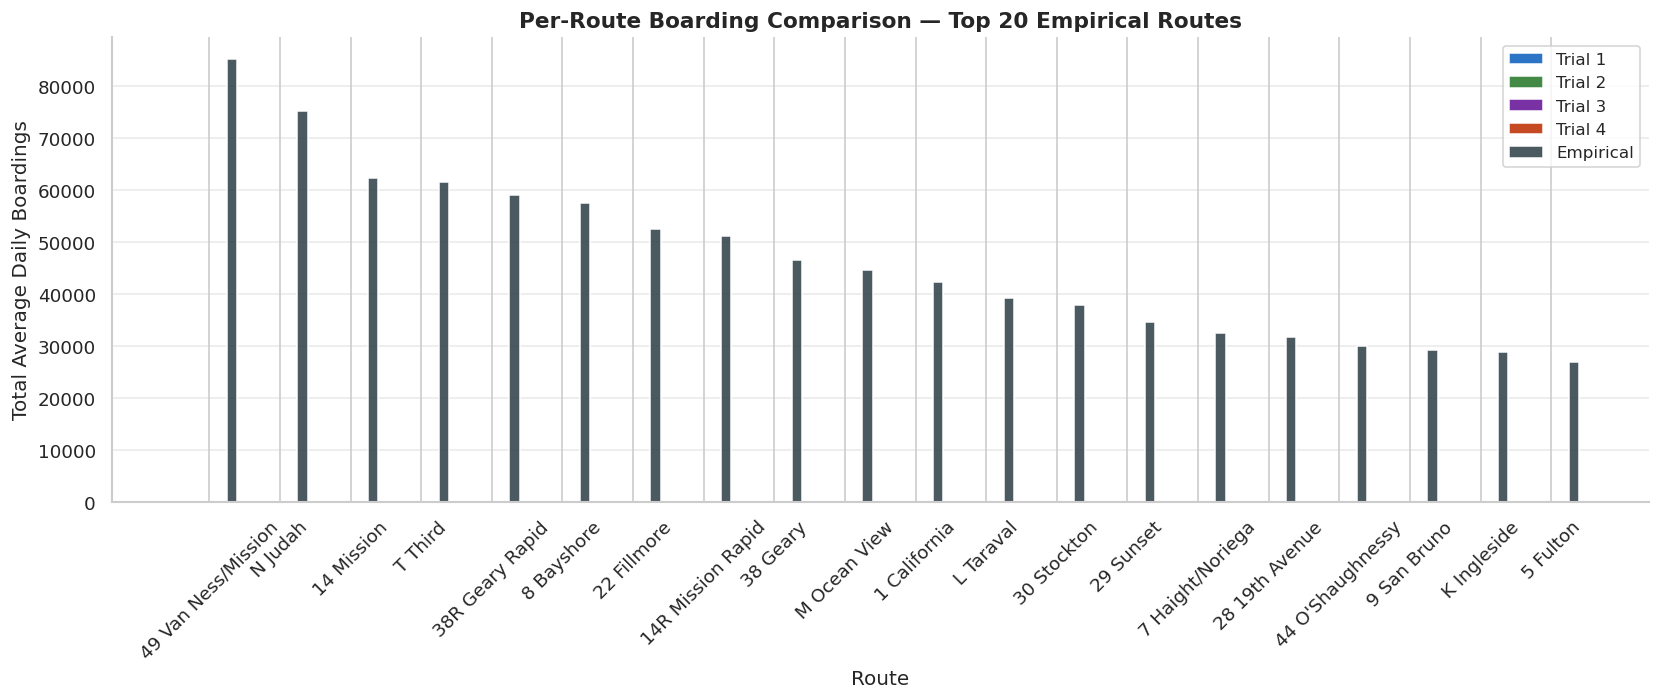

In [33]:
# Visualization: Per-Route Grouped Bar — Top 20 Routes

top20     = combined_df.loc[top20_routes]
x         = np.arange(len(top20))
n_cols    = len(top20.columns)
width     = 0.8 / n_cols
colors_gb = ["#1565C0", "#2E7D32", "#6A1B9A", "#BF360C", "#37474F"]

fig, ax = plt.subplots(figsize=(14, 6))
for i, col in enumerate(top20.columns):
    offset = (i - n_cols / 2 + 0.5) * width
    ax.bar(x + offset, top20[col], width=width * 0.92,
           label=col, color=colors_gb[i % len(colors_gb)],
           edgecolor="white", alpha=0.9)
ax.set_title("Per-Route Boarding Comparison — Top 20 Empirical Routes", fontsize=13, fontweight="bold")
ax.set_xlabel("Route")
ax.set_ylabel("Total Average Daily Boardings")
ax.set_xticks(x)
ax.set_xticklabels(top20.index.astype(str), rotation=45)
ax.legend(fontsize=10, loc="upper right")
ax.grid(axis="y", alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()

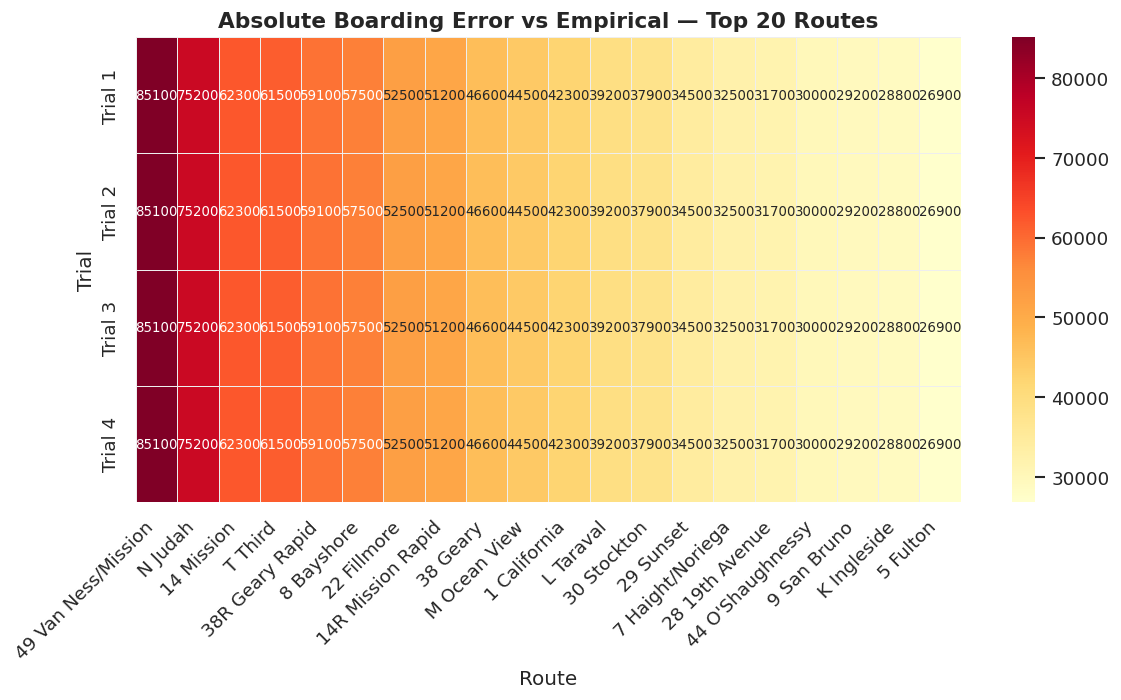

In [34]:
# Visualization: Absolute Error Heatmap — Trial vs Empirical (Top 20 Routes)

trial_cols = [c for c in combined_df.columns if c != "Empirical"]
error_df   = pd.DataFrame(index=top20_routes)
for col in trial_cols:
    error_df[col] = (combined_df.loc[top20_routes, col] - combined_df.loc[top20_routes, "Empirical"]).abs()

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    error_df.T,
    annot=True, fmt=".0f",
    cmap="YlOrRd",
    linewidths=0.5, linecolor="#eee",
    ax=ax,
    annot_kws={"fontsize": 8}
)
ax.set_title("Absolute Boarding Error vs Empirical — Top 20 Routes", fontsize=13, fontweight="bold")
ax.set_xlabel("Route")
ax.set_ylabel("Trial")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

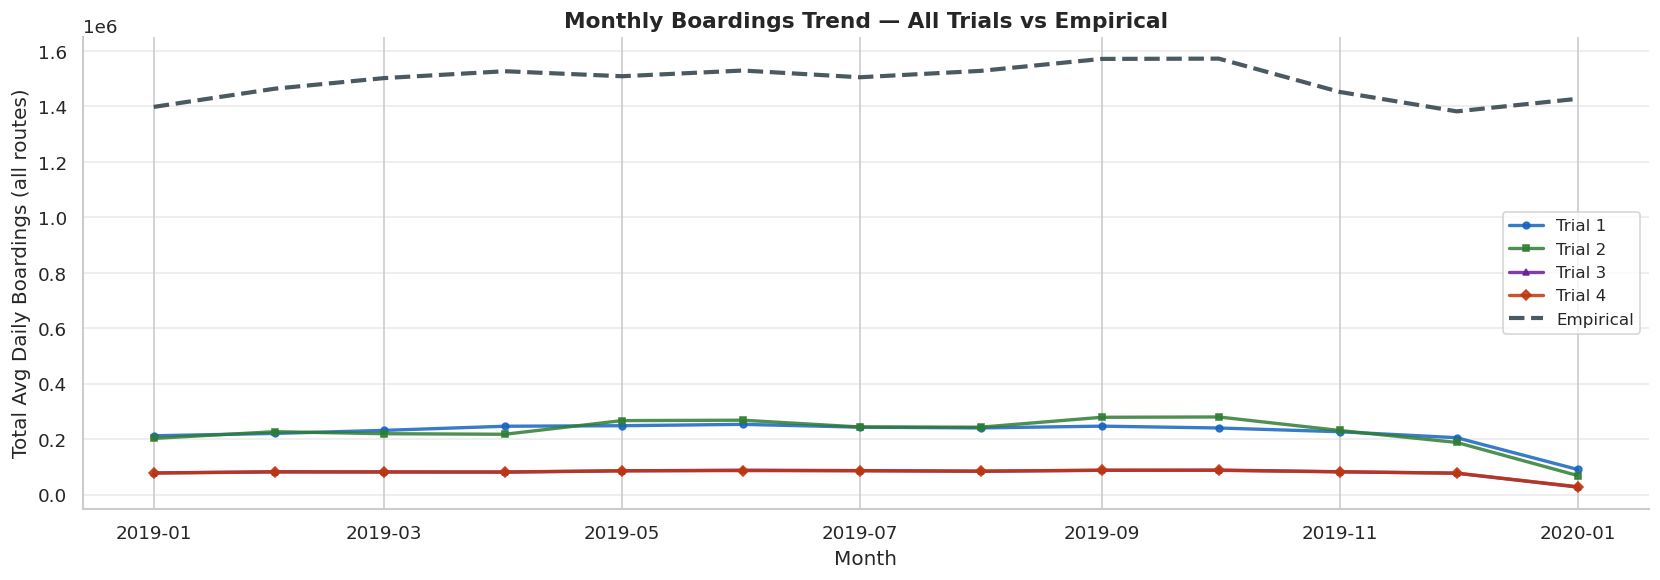

In [35]:
# Visualization: Monthly Ridership Trend — All Trials Overlaid vs Empirical

colors_r = ["#1565C0", "#2E7D32", "#6A1B9A", "#BF360C"]
markers  = ["o", "s", "^", "D"]

# Determine the date range covered by the trials
trial_months = pd.concat(
    [df[["Month"]] for df in trials.values() if not df.empty and "Month" in df.columns]
).dropna()
trial_start = trial_months["Month"].min()
trial_end   = trial_months["Month"].max()

fig, ax = plt.subplots(figsize=(14, 5))
for i, (t_name, df) in enumerate(trials.items()):
    if not df.empty and "Month" in df.columns and df["Month"].notna().any():
        monthly = df.groupby("Month")["Average Daily Boardings"].sum().reset_index()
        ax.plot(monthly["Month"], monthly["Average Daily Boardings"],
                marker=markers[i], linewidth=2, color=colors_r[i],
                label=t_name, alpha=0.85, markersize=4)

# Clip empirical to the same date window as the trials
emp_monthly = rd.groupby("Month")["Average Daily Boardings"].sum().reset_index()
emp_monthly = emp_monthly[
    (emp_monthly["Month"] >= trial_start) & (emp_monthly["Month"] <= trial_end)
]
ax.plot(emp_monthly["Month"], emp_monthly["Average Daily Boardings"],
        linewidth=2.5, color="#37474F", linestyle="--",
        label="Empirical", alpha=0.9)

ax.set_title("Monthly Boardings Trend — All Trials vs Empirical", fontsize=13, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Total Avg Daily Boardings (all routes)")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()

In [36]:
# Summary Performance Table

rows = []
for col in [c for c in combined_df.columns if c != "Empirical"]:
    emp = combined_df["Empirical"]
    sim = combined_df[col]

    shared_idx  = emp[(emp > 0) & (sim > 0)].index
    emp_shared  = emp.loc[shared_idx]
    sim_shared  = sim.loc[shared_idx]

    total_sim   = sim.sum()
    total_emp   = emp.sum()
    pct_diff    = (total_sim - total_emp) / (total_emp + 1e-9) * 100
    spearman    = stats.spearmanr(sim_shared, emp_shared)[0] if len(shared_idx) > 2 else np.nan
    pearson     = stats.pearsonr(sim_shared, emp_shared)[0]  if len(shared_idx) > 2 else np.nan
    mae         = (sim_shared - emp_shared).abs().mean()
    mape        = ((sim_shared - emp_shared).abs() / (emp_shared + 1e-9)).mean() * 100

    rows.append({
        "Trial"               : col,
        "Total Sim Boardings" : f"{total_sim:,.0f}",
        "Total Emp Boardings" : f"{total_emp:,.0f}",
        "Volume Diff (%)"     : f"{pct_diff:+.1f}%",
        "Spearman ρ"          : f"{spearman:.4f}" if not np.isnan(spearman) else "N/A",
        "Pearson r"           : f"{pearson:.4f}"  if not np.isnan(pearson)  else "N/A",
        "MAE"                 : f"{mae:,.1f}",
        "MAPE (%)"            : f"{mape:.1f}%",
    })

summary_df = pd.DataFrame(rows).set_index("Trial")

print("Summary Performance Table — Trial vs Empirical SFMTA Baseline")
print()
display(summary_df)

Summary Performance Table — Trial vs Empirical SFMTA Baseline



,Total Sim Boardings,Total Emp Boardings,Volume Diff (%),Spearman ρ,Pearson r,MAE,MAPE (%)
Trial,,,,,,,
Trial 1,"2,907,480","1,206,700",+140.9%,N/A,N/A,nan,nan%
Trial 2,"2,937,085","1,206,700",+143.4%,N/A,N/A,nan,nan%
Trial 3,"1,032,755","1,206,700",-14.4%,N/A,N/A,nan,nan%
Trial 4,"1,031,210","1,206,700",-14.5%,N/A,N/A,nan,nan%


---

## References
List out the resources and references used for cultivating this analysis file.

- **SFMTA Ridership Data:** https://www.sfmta.com/reports/ridership-statistics
- **GTFS Specification:** https://gtfs.org/schedule/reference/
- **SFMTA Developer Resources:** https://www.sfmta.com/reports/gtfs-transit-data
- **ACS Table C08132 — Commute Departure Times:** https://data.census.gov/table/ACSDT1Y2024.C08132
- **LODES LEHD Origin-Destination:** https://lehd.ces.census.gov/data/
- **Decennial Census PL 94-171:** https://www.census.gov/programs-surveys/decennial-census/about/rdo/summary-files.html
- **SF Land Use Dataset:** https://data.sfgov.org/Housing-and-Buildings/Land-Use/us3s-fp9q
- **SciPy Statistics:** https://docs.scipy.org/doc/scipy/reference/stats.html
- **Seaborn Visualization Library:** https://seaborn.pydata.org/